In [1]:
import sys
import math
import os
import torch
sys.path.append(os.path.abspath('../'))

from natsort import natsorted
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
from tqdm import tqdm

# Add both project root and src/ to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))  # <-- add this

from src.dataset import deterministic_sample, create_dataloader
from src.egnn import EGNN
# from mlp_baseline import MLPBaseline
from src.fm import FlowMatching
from src.pbc_config import wrap, min_image
from src.utils import load_config, gpu_knn_graph_pbc_batch, scale_thetas, SinusoidalThetaEmbedding, \
    compute_local_density, get_activation_fn
from src.dataset import create_dataloader

from src.validation import get_tpcf

import numpy as np
import pandas as pd 
import torch.nn as nn
import matplotlib.pyplot as plt
import networkx as nx

BOX = {"LX": 1000.0, "LY": 1000.0, "LZ": 1000.0}

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_kwargs = {'batch_size': 1}
test_kwargs = {'batch_size': 1}


In [3]:
train_dl, valid_dl, train_sampler = create_dataloader(
    cosmologies_dir="../../Data",
    cosmologies_info_dir="../../Data",
    distributed=False,    ########## DDP ###########
    train_kwargs=train_kwargs, 
    valid_kwargs=test_kwargs,
    rotations=False,
    translations=False,
    cosm_param=None,
    coupling=False,
    optimal_transport=False
    )

In [4]:
sample = next(iter(train_dl)).x
sample.shape

torch.Size([5000, 3])

In [5]:
L = 370
subgraph_sizes = []

for idx, item in enumerate(train_dl):
    pos = item.x * 1000  # (N, 3) back to h^-1 Mpc

    corner = torch.rand(3) * 1000  # sample anywhere in the box
    shifted = wrap(pos - corner, 1000, 1000, 1000)  # PBC wrapping
    mask = (shifted[:, 0] < L) & (shifted[:, 1] < L) & (shifted[:, 2] < L)
    
    subgraph = shifted[mask]  # (n_inside, 3), already re-centered to [0, L)
    subgraph_sizes.append(subgraph.shape[0])

sizes = torch.tensor(subgraph_sizes)
print(f"L={L} | mean={sizes.float().mean():.1f}, std={sizes.float().std():.1f}, "
      f"min={sizes.min()}, max={sizes.max()}")

L=370 | mean=254.9, std=33.4, min=105, max=576


In [6]:
"""
Subbox size analysis for Quijote halo catalogs.
Sweep L, sample random subboxes with PBC wrapping, 
and check the distribution of halo counts.

Run this as a notebook or script — adjust `DATA_DIR` to your paths.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ──────────────────────────────────────────────
DATA_DIR = "../../Data"
SPLIT = "train"
BOX_SIZE = 1000.0  # h^-1 Mpc
TARGET_N = 256
N_RANDOM_PLACEMENTS = 100  # random subbox positions per simulation per L
L_VALUES = np.arange(250, 500, 10)  # sweep range for subbox side length

# ── Load data ───────────────────────────────────────────
halos = np.load(Path(DATA_DIR) / f"{SPLIT}_halos.npy")  # (N_sims, 5000, 7)
N_sims = halos.shape[0]
print(f"Loaded {N_sims} simulations, each with {halos.shape[1]} halos")

# Use a subset of simulations to keep this fast
N_sims_sample = min(200, N_sims)
sim_indices = np.random.choice(N_sims, N_sims_sample, replace=False)
print(f"Using {N_sims_sample} simulations for analysis")

# ── Subbox extraction with PBC ──────────────────────────
def count_halos_in_subbox(positions, corner, L, box_size=1000.0):
    """
    Count halos inside a cubic subbox [corner, corner+L)^3 with PBC wrapping.
    """
    # Shift so corner is at origin, then wrap
    shifted = (positions - corner) % box_size
    # Halos inside the subbox have all coords in [0, L)
    inside = np.all(shifted < L, axis=1)
    return inside.sum()

# ── Sweep L values ──────────────────────────────────────
results = {}

for L in L_VALUES:
    counts = []
    for sim_idx in sim_indices:
        pos = halos[sim_idx, :, :3]  # (5000, 3) positions in [0, 1000)
        for _ in range(N_RANDOM_PLACEMENTS):
            corner = np.random.uniform(0, BOX_SIZE, size=3)
            n = count_halos_in_subbox(pos, corner, L)
            counts.append(n)
    
    counts = np.array(counts)
    results[L] = counts
    print(f"L={L:>6.1f} | mean={counts.mean():.1f}, median={np.median(counts):.1f}, "
          f"std={counts.std():.1f}, min={counts.min()}, max={counts.max()}, "
          f"frac in [200,320]: {np.mean((counts >= 200) & (counts <= 320)):.2%}")

# ── Plot 1: Mean halo count vs L ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

means = [results[L].mean() for L in L_VALUES]
stds = [results[L].std() for L in L_VALUES]

ax = axes[0]
ax.plot(L_VALUES, means, 'b-o', markersize=3)
ax.fill_between(L_VALUES, np.array(means) - np.array(stds), 
                np.array(means) + np.array(stds), alpha=0.2)
ax.axhline(TARGET_N, color='r', linestyle='--', label=f'Target = {TARGET_N}')
ax.set_xlabel('Subbox side length L [h⁻¹ Mpc]')
ax.set_ylabel('Halo count')
ax.set_title('Mean halo count vs L')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Distribution at a few key L values ──────────
ax = axes[1]
# Find L closest to target
best_L_idx = np.argmin(np.abs(np.array(means) - TARGET_N))
best_L = L_VALUES[best_L_idx]
show_Ls = [best_L - 30, best_L, best_L + 30]
show_Ls = [L for L in show_Ls if L in results]

for L in show_Ls:
    ax.hist(results[L], bins=50, alpha=0.4, label=f'L={L:.0f}', density=True)
ax.axvline(TARGET_N, color='r', linestyle='--', label=f'Target = {TARGET_N}')
ax.set_xlabel('Halo count in subbox')
ax.set_ylabel('Density')
ax.set_title('Halo count distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 3: Fraction of subboxes within acceptable range ─
ax = axes[2]
for lo, hi, label in [(200, 320, '200–320'), (220, 300, '220–300'), (230, 280, '230–280')]:
    fracs = [np.mean((results[L] >= lo) & (results[L] <= hi)) for L in L_VALUES]
    ax.plot(L_VALUES, fracs, '-o', markersize=3, label=f'{label}')
ax.set_xlabel('Subbox side length L [h⁻¹ Mpc]')
ax.set_ylabel('Fraction of subboxes in range')
ax.set_title('Acceptance rate vs L')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('subbox_L_analysis.png', dpi=150)
plt.show()

# ── Print recommendation ────────────────────────────────
print(f"\n{'='*60}")
print(f"Best L (mean closest to {TARGET_N}): {best_L:.0f} h⁻¹ Mpc")
print(f"  Mean count: {results[best_L].mean():.1f}")
print(f"  Std:        {results[best_L].std():.1f}")
print(f"  Median:     {np.median(results[best_L]):.1f}")
print(f"  [200, 320]: {np.mean((results[best_L] >= 200) & (results[best_L] <= 320)):.1%}")
print(f"{'='*60}")

Loaded 1800 simulations, each with 5000 halos
Using 200 simulations for analysis
L= 250.0 | mean=78.1, median=77.0, std=16.7, min=3, max=263, frac in [200,320]: 0.03%


KeyboardInterrupt: 

In [ ]:
def extract_subbox(halos, L=370, box_size=1000):
    """
    Extract a single subbox from a (5000, 7) halo array.
    Columns: [x, y, z, vx, vy, vz, mass]
    
    Returns the subbox halos re-centered to [0, L)³, or None if empty.
    """
    corner = np.random.uniform(0, box_size, size=3)
    
    pos = halos[:, :3]
    shifted_pos = wrap(pos - corner, **BOX)
    
    mask = np.all(shifted_pos < L, axis=1)
    
    if mask.sum() == 0:
        return None
    
    sub_halos = halos[mask].copy()
    sub_halos[:, :3] = shifted_pos[mask]
    
    return sub_halos

In [20]:
DATA_DIR = "../../Data"
OUT_DIR = "../../../T256/Data/subboxes"
L = 370
BOX_SIZE = 1000
N_SUBBOXES = 10
COUNT_RANGE = (200, 320)
MAX_COUNT = 320

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

for split in ["train", "test"]:
    halos_all = np.load(Path(DATA_DIR) / f"{split}_halos.npy")
    params_df = pd.read_csv(Path(DATA_DIR) / f"{split}_cosmology.csv")
    
    N_sims = halos_all.shape[0]
    
    subbox_list = []
    counts_list = []
    params_list = []
    
    for sim_idx in tqdm(range(N_sims)):
        halos = halos_all[sim_idx]  # (5000, 7)
        
        for _ in range(N_SUBBOXES):
            corner = np.random.uniform(0, BOX_SIZE, size=3)
            
            pos = halos[:, :3]
            shifted_pos = (pos - corner) % BOX_SIZE
            mask = np.all(shifted_pos < L, axis=1)
            
            count = mask.sum()
            if count < COUNT_RANGE[0] or count > COUNT_RANGE[1]:
                continue
            
            sub = halos[mask].copy()
            sub[:, :3] = shifted_pos[mask]
            
            padded = np.zeros((MAX_COUNT, 7), dtype=np.float32)
            padded[:count] = sub
            
            subbox_list.append(padded)
            counts_list.append(count)
            params_list.append(params_df.values[sim_idx])
    
    subbox_arr = np.stack(subbox_list)
    counts_arr = np.array(counts_list)
    
    np.save(Path(OUT_DIR) / f"{split}_subbox_halos.npy", subbox_arr)
    np.save(Path(OUT_DIR) / f"{split}_subbox_counts.npy", counts_arr)
    
    out_params_df = pd.DataFrame(params_list, columns=params_df.columns)
    out_params_df.to_csv(Path(OUT_DIR) / f"{split}_cosmology.csv", index=False)
    
    print(f"{split}: {len(subbox_list)} subboxes from {N_sims} simulations "
          f"(mean count: {counts_arr.mean():.1f}, std: {counts_arr.std():.1f})")

100%|██████████| 1800/1800 [00:08<00:00, 207.38it/s]


train: 16970 subboxes from 1800 simulations (mean count: 253.8, std: 23.5)


100%|██████████| 200/200 [00:00<00:00, 206.05it/s]

test: 1887 subboxes from 200 simulations (mean count: 254.1, std: 23.2)


In [12]:
16979 / (16979 + 1882)

0.9002173797783787

[[ 1.1230655e+02  7.0163641e+02  6.4970850e+02 ... -3.6753171e+02
   2.6911716e+02  1.1177907e+14]
 [ 1.3720975e+02  5.5704095e+02  7.4714941e+02 ...  8.7824730e+01
  -3.8612592e+02  1.1177907e+14]
 [ 9.9483185e+01  2.4812627e+02  9.3284473e+02 ...  2.2627824e+02
   6.5559341e+01  1.1177907e+14]
 ...
 [ 5.5340637e+02  8.5665936e+02  3.0290207e+02 ... -1.9243851e+02
  -1.9093851e+02  2.8377018e+15]
 [ 2.2660483e+02  6.7673639e+02  7.5723669e+02 ... -1.7667873e+02
  -3.9683178e+01  3.4600938e+15]
 [ 6.7735938e+02  6.6435913e+01  2.6432083e+02 ... -1.3591466e+02
   4.4045883e+01  4.2433713e+15]]


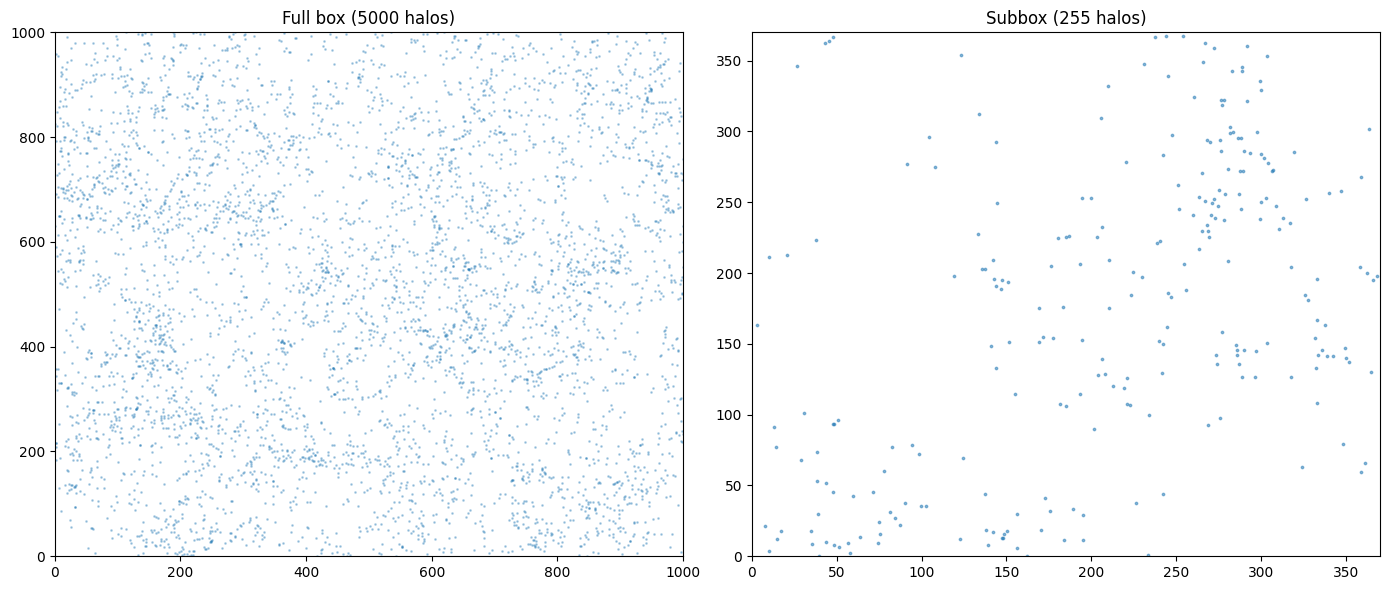

In [18]:
# Pick a simulation
sim_idx = 0
train_halos = np.load("../../Data/train_halos.npy")
halos = train_halos[sim_idx]  # (5000, 7)
print(halos)

# Extract a subbox manually
corner = np.random.uniform(0, 1000, size=3)
shifted = (halos[:, :3] - corner) % 1000
mask = np.all(shifted < 370, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full box, project onto x-y plane
ax = axes[0]
ax.scatter(halos[:, 0], halos[:, 1], s=1, alpha=0.3, label='all halos')
# Show the subbox region (in original coordinates)
ax.set_title(f'Full box (5000 halos)')
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)

# Right: the extracted subbox, re-centered
ax = axes[1]
sub_pos = shifted[mask]
ax.scatter(sub_pos[:, 0], sub_pos[:, 1], s=3, alpha=0.5)
ax.set_title(f'Subbox ({mask.sum()} halos)')
ax.set_xlim(0, 370)
ax.set_ylim(0, 370)

plt.tight_layout()
plt.show()

In [19]:
# Load saved subboxes
subbox_halos = np.load("../../../T256/Data/subboxes/train_subbox_halos.npy")
subbox_counts = np.load("../../../T256/Data/subboxes/train_subbox_counts.npy")
original_halos = np.load("../../Data/train_halos.npy")

# Pick a subbox
idx = 0
n = subbox_counts[idx]
sub = subbox_halos[idx, :n]  # (n, 7)

# Its parent simulation (first 10 subboxes come from sim 0, roughly)
sim_idx = 0
orig = original_halos[sim_idx]  # (5000, 7)

# The masses weren't changed, so every subbox halo's mass 
# should match a halo in the original
sub_masses = set(sub[:, -1].tolist())
orig_masses = set(orig[:, -1].tolist())
print(f"All subbox masses found in original: {sub_masses.issubset(orig_masses)}")

All subbox masses found in original: True
